## dynamical.org Examples

All of the models used by hefty for solar and wind can be accessed via [dynamical.org](https://dynamical.org) using `priority='dynamical'`, with some limitations for cycle/initialization times. A list of model/resource type combinations and corresponding dynamical availability is available in hefty GitHub issue [#64](https://github.com/williamhobbs/hefty/issues/64#issuecomment-4939703931).

Data from dynamical are in zarr format, and most models are time-optimized, meaning that the amount of data required to be downloaded is relatively small, and it can be very fast. **Up to 10X faster than downloading full grib files**.

In [1]:
import matplotlib.pyplot as plt
from hefty.pv_model import model_pv_power
from hefty.solar import get_solar_forecast, get_solar_forecast_ensemble
import pandas as pd

Let's revisit the example from [more_solar_examples.ipynb](examples\more_solar_examples.ipynb):

In [2]:
# Define specs for 4 plants. Two tracking, two fixed-tilt. 
# This could also be stored in a csv or spreadsheet and read in as a dataframe.
plants_dict = {
    'latitude': [33.5, 33.8, 32.8, 32.1],
    'longitude': [-86.8, -84.4, -83.6, -81.1],
    'mount_type': ['single-axis', 'fixed', 'single-axis', 'fixed'],
    'gcr': [0.4, 0.6, 0.35, 0.35],
    'nameplate_dc': [120, 60, 100, 60],
    'nameplate_ac': [100, 50, 80, 50],
    'dc_loss_fraction': [0.1, 0.1, 0.2, 0.1],
    'gamma_pdc': [-0.003, -0.003, -0.003, -0.003],
    'shade_loss_model': ['linear', 'non-linear_simple_twin_module', 'non-linear_simple', 'non-linear_simple'],
    'backtrack': [False, None, True, None],
    'max_tracker_angle': [60, None, 50, None],
    'fixed_azimuth': [None, 180, None, 180],
    'fixed_tilt': [None, 20, None, 15],
}

# create a dataframe
plants_df = pd.DataFrame(plants_dict)

latitudes = plants_df.latitude.values
longitudes = plants_df.longitude.values
num_sites = len(latitudes)

But use `priority='dynamical'` instead.

Because IFS single is not available from dynamical until 2024-11-12*, we will adjust the dates.

*_dynamical only has IFS Ensemble, and starting 2024-11-12, the IFS Ensemble control member became the same as IFS single, see the 2026-July-15 [comment](https://github.com/williamhobbs/hefty/issues/64#issuecomment-4982713402) on GH issue #64 for more details._

In [3]:
# a range of initialization dates
dates = pd.date_range(start = '2025-06-01 0:00', end = '2025-06-03 0:00', freq = '1D')

dfs = []
for date in dates: # loop through dates
    resource_data_temp = get_solar_forecast(
        latitude=latitudes,
        longitude=longitudes,
        init_date=date, # <-- this gets changed in each loop
        run_length=18, # 18 hours are included in the forecast
        lead_time_to_start=9, # forecast starts 9 hours out from the init_date
        model='ifs',
        attempts=3,
        priority='dynamical',  # use dynamical
    )
    dfs.append(resource_data_temp) # append
resource_data = pd.concat(dfs) # concatenate into one large dataframe
resource_data['albedo'] = 0.2 # fill in albedo data

# calculate power for each plant
power_dfs = {}
num_sites = len(plants_df.index)
for i in range(num_sites):
    plant_data_dict = plants_df.loc[i].dropna().to_dict()
    resource_data_temp = resource_data[resource_data['point']==i].copy()
    power_ac_expected, resource_data_updated = model_pv_power(
        resource_data=resource_data_temp,
        **plant_data_dict,
    )
    power_dfs[i] = power_ac_expected

<Axes: xlabel='valid_time'>

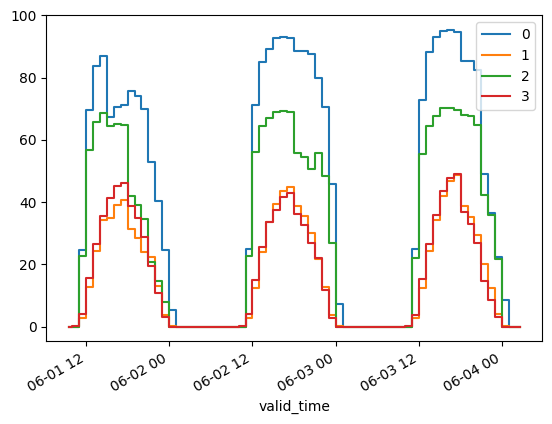

In [4]:
# plot
pd.concat(power_dfs,axis=1).plot(drawstyle='steps-mid')

That should have taken **20-30 seconds**, depending on your hardware and network connection speed. For comparison, downloading 3 days of forecasts in [more_solar_examples.ipynb](examples\more_solar_examples.ipynb) with `priority='azure'` and `get_solar_forecast` took about **4-6 minutes**, and with `get_solar_forecast_fast` (leveraging parallel downloads with FastHerbie) it took **1-2 minutes**.

*Note that running the same query a second time, if you haven't deleted grib files from the `~/data` folder, will be slightly faster for sources other than dynamical, as the grib files don't have to be downloaded a second time. With dynamical, nothing is stored locally, so data has to be re-downloaded each time.*

Now, let's try dynamical with an example from [ensemble_example.ipynb](examples\ensemble_example.ipynb). Note that we have to adjust the initialization time again.

In [5]:
init_date = pd.to_datetime('2025-09-05 00:00')
latitude = [33.5, 32, 33]
longitude = [-88.5, -89, -91]
num_members = 4 # up to 50 for IFS
run_length = 48 # needs to be multiple of 6
lead_time_to_start = 30 # needs to be a multiple of 6
model = 'ifs_ens'
attempts = 4
priority = 'dynamical'

In [6]:
resource_all = get_solar_forecast_ensemble(
    latitude, longitude, init_date, run_length,
    lead_time_to_start, model, attempts, priority=priority)

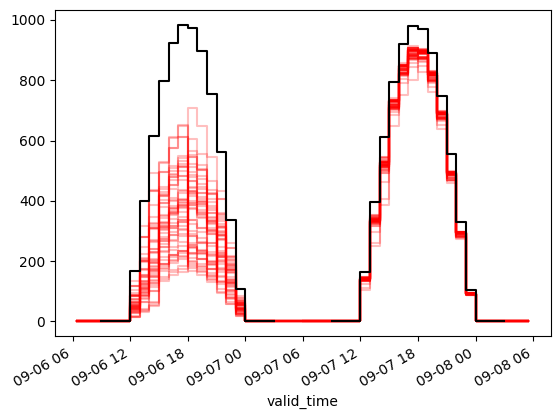

In [7]:
resource = resource_all.copy()
member_list = resource['member'].unique()
point = 0
for member in member_list:
    resource[(resource['member'] == member) & (resource['point'] == point)]['ghi'].plot(drawstyle='steps-mid', color='red', alpha=0.25)
resource[(resource['member'] == member_list[0]) & (resource['point'] == point)]['ghi_clear'].plot(label='clear sky', color='black', drawstyle='steps-mid')
plt.show()

That took about **30 seconds** to get from dynamical, while a similar query from Google took about **7 minutes**. 

And now with GEFS:

In [8]:
resource_gefs = get_solar_forecast_ensemble(
    latitude, longitude, init_date, run_length,
    lead_time_to_start, model='gefs', attempts=attempts, priority=priority)

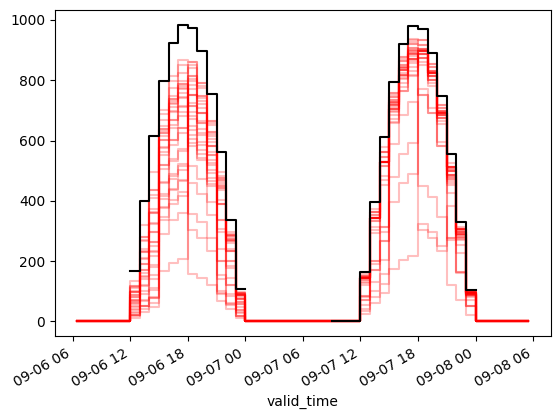

In [9]:
resource = resource_gefs.copy()
member_list = resource['member'].unique()
point = 0
for member in member_list:
    resource[(resource['member'] == member) & (resource['point'] == point)]['ghi'].plot(drawstyle='steps-mid', color='red', alpha=0.25)
resource[(resource['member'] == member_list[0]) & (resource['point'] == point)]['ghi_clear'].plot(label='clear sky', color='black', drawstyle='steps-mid')
plt.show()

That took about **2 minutes** compared with **7-12 minutes** previously. 

And then running it again, but with `get_ens_temp=True` and `get_ens_wind=True`

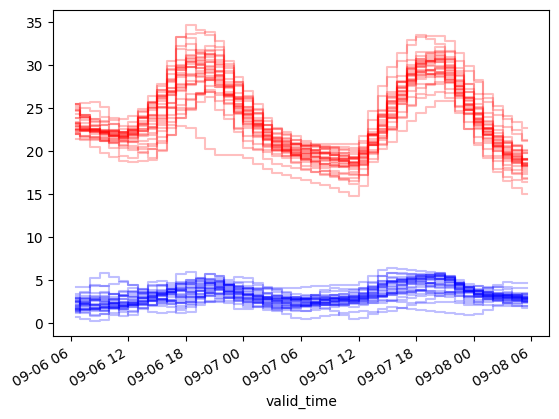

In [10]:
resource_gefs_all = get_solar_forecast_ensemble(
    latitude, longitude, init_date, run_length,
    lead_time_to_start, model='gefs', attempts=attempts,
    priority=priority, get_ens_temp=True, get_ens_wind=True)

resource = resource_gefs_all.copy()
member_list = resource['member'].unique()
point = 0
for member in member_list:
    resource[(resource['member'] == member) & (resource['point'] == point)]['temp_air'].plot(drawstyle='steps-mid', color='red', alpha=0.25)
    resource[(resource['member'] == member) & (resource['point'] == point)]['wind_speed'].plot(drawstyle='steps-mid', color='blue', alpha=0.25)
plt.show()

About **2.5 minutes** compared with an additional **10-12 minutes** previously. 

And the wind examples from [wind_example.ipynb](examples\wind_example.ipynb):

In [11]:
from hefty.wind import get_wind_forecast

In [16]:
latitude, longitude = 41.03325, -70.61667 # vineyard wind
init_date = '2025-08-20 12:00' # datetime the forecast model was initialized
run_length = 36
lead_time_to_start = 12

resource_data_gfs = get_wind_forecast(
    latitude,
    longitude,
    init_date,
    run_length=run_length, 
    lead_time_to_start=lead_time_to_start, 
    model='gfs',
    priority='dynamical'
)

resource_data_gefs_c = get_wind_forecast(
    latitude,
    longitude,
    init_date='2025-08-20 0:00',  # only 0Z cycle with dynamical
    run_length=run_length, 
    lead_time_to_start=lead_time_to_start+12,  # add 12h to adjust for using 0z cycle
    model='gefs',
    member='c00',
    priority='dynamical'
)

resource_data_hrrr = get_wind_forecast(
    latitude,
    longitude,
    init_date,
    run_length=run_length, 
    lead_time_to_start=lead_time_to_start, 
    model='hrrr',
    priority='dynamical'
)

resource_data_ifs = get_wind_forecast(
    latitude,
    longitude,
    init_date='2025-08-20 0:00',  # only 0Z cycle with dynamical
    run_length=run_length, 
    lead_time_to_start=lead_time_to_start+12,  # add 12h to adjust for using 0z cycle
    model='ifs',
    priority='dynamical'
)

resource_data_aifs = get_wind_forecast(
    latitude,
    longitude,
    init_date,
    run_length=run_length, 
    lead_time_to_start=lead_time_to_start, 
    model='aifs',
    priority='dynamical'
)

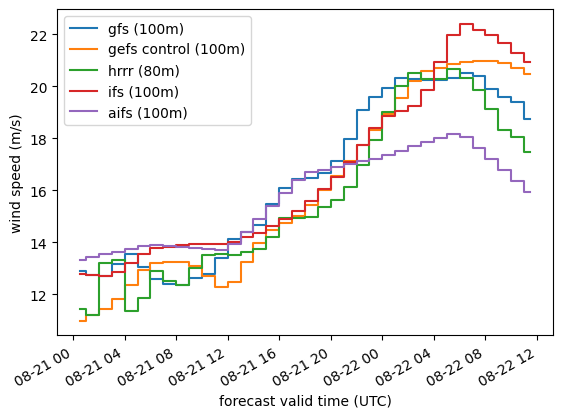

In [17]:
resource_data_gfs['wind_speed_100m'].plot(drawstyle='steps-mid', label='gfs (100m)')
resource_data_gefs_c['wind_speed_100m'].plot(drawstyle='steps-mid', label='gefs control (100m)')
resource_data_hrrr['wind_speed_80m'].plot(drawstyle='steps-mid', label='hrrr (80m)')
resource_data_ifs['wind_speed_100m'].plot(drawstyle='steps-mid', label='ifs (100m)')
resource_data_aifs['wind_speed_100m'].plot(drawstyle='steps-mid', label='aifs (100m)')
plt.ylabel('wind speed (m/s)')
plt.xlabel('forecast valid time (UTC)')
plt.legend()
plt.show()

That took less than **1 minute**, compared with about **15 minutes** previously. 

-----
_This document/data/output/Results is/are based on data and products of the European Centre for Medium-Range Weather Forecasts (ECMWF). © 2026 European Centre for Medium-Range Weather Forecasts (ECMWF), www.ecmwf.int. This data is published under a Creative Commons Attribution 4.0 International (CC BY 4.0). https://creativecommons.org/licenses/by/4.0/. ECMWF does not accept any liability whatsoever for any error or omission in the data, their availability, or for any loss or damage arising from their use._

_ECMWF Data have been modified using the functions included in the hefty Python package (e.g., interpolation to hourly values)._